# Example on how to run the RadCLss VAP using the radclss package.

This notebook reproduces the same workflow for RadCLss that runs in the ARM Data Integration (ADI) system. It shows an example for an hour of data, using the same processing path as the production VAP. See the [ADI repository](https://github.com/ARM-DOE/ADI) for the surrounding data-processing framework. All ARM data are downloaded through ARM Live. NEXRAD data are downloaded using subroutines inside radclss.

**What you need:** an ARM ADC account and an ARM Live access token
([adc.arm.gov/armlive](https://adc.arm.gov/armlive/)), plus enough disk for the radar volumes. The
NEXRAD data radclss pulls in comes from the public `unidata-nexrad-level2` S3 bucket and needs no
credentials.

## 1. Imports

In [1]:
import glob
import os
from getpass import getpass
from pathlib import Path

import act
import cmweather  # noqa: F401 - registers the ChaseSpectral and balance colormaps
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import radclss

print(f"act {act.__version__}")
print(f"radclss {Path(radclss.__file__).parent}")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

act 0.1.5.post1471+dirty
radclss /Users/rjackson/radclss/src/radclss


## 2. Configuration

The following sections shows all of the configuration variables that are taken into account when processing RadCLss. RadCLss processes a full 24 hour interval. That is a lot of data to pull over the network for an example: BNF CSAPR2 `cfr.a1` volumes run a few hundred MB each, and because the time coordinate ends up on a 1 minute grid, radclss fetches a NEXRAD column for every
minute inside the radar time range. The default below is therefore the most active part of the day
rather than all of it. Set `WINDOW_START`/`WINDOW_END` to `"000000"`/`"235959"` to reproduce the
full VAP processing interval.

### Configuration variables

Edit the values in the code cell below to change the site, time period, processing options, or output location. Most users only need to change `DATE`, `WINDOW_START`, `WINDOW_END`, and possibly `DATA_DIR`.

| Variable | What it controls | Expected value / example |
| --- | --- | --- |
| `SITE` | ARM site identifier used to find the site's data and build ARM datastream names. | Lowercase site code, such as `"bnf"`. |
| `BASE_STATION` | Main station used as the reference for the retrieval and for the ARM output filename. | Station/facility code, such as `"M1"`. |
| `DATE` | UTC calendar date for the data to download and process. | Eight digits in `YYYYMMDD` format, such as `"20250521"`. |
| `WINDOW_START` | Beginning of the time window to process. | UTC time as six digits `HHMMSS`, such as `"000000"`. |
| `WINDOW_END` | End of the time window to process. | UTC time as six digits `HHMMSS`, such as `"050000"`; use `"235959"` for the end of the day. |
| `HEIGHT_BINS` | Vertical grid used for the retrieved radar columns. The values are heights above ground in meters. | A NumPy array; the default creates levels from 0 to 14,900 m every 100 m. |
| `DOD_VERSION` | Version of the ARM data-description rules used to define the output variables and metadata. | Version string, such as `"1.0"`. |
| `DOD_FILE` | Optional path to a local file that describes the output variables. Leave as `None` to use radclss's built-in/default behavior. | `None` or a path such as `Path("conf/radclss.c0.json")`. |
| `NEXRAD` | Whether to add NEXRAD data to the retrieval. This can substantially increase downloads and processing time. | `True` to include NEXRAD; `False` to skip it. |
| `SERIAL` | Whether to process the data one step at a time. Serial processing generally uses less memory but may be slower. | `True` or `False`. |
| `DATA_DIR` | Local directory where downloaded input data and the generated output are stored. The `RADCLSS_DATA_DIR` environment variable can override its parent directory. | A `Path`, such as `Path("~/radclss_data") / SITE`. |
| `OUTPUT_FILE` | Full path and filename for the final NetCDF output file. | A `Path`; normally constructed from the site, station, and date. |
| `PLOT_STATION` | Station whose data are selected for plots later in the notebook. It does not change the retrieval itself. | Station/facility code present in the output, such as `"M1"`. |

In [2]:
SITE = "bnf"
BASE_STATION = "M1"  # dsproc.core.get_facility() in the VAP
DATE = "20250521"

WINDOW_START = "000000"
WINDOW_END = "050000"

# Arguments to radclss.core.radclss, matching radclss_vap/__main__.py
HEIGHT_BINS = np.arange(0, 15000, 100.0)
DOD_VERSION = "1.0"  # DOD_VERSION["bnf"] in the VAP
DOD_FILE = None  # the VAP points this at its cached conf/radclss.c0.json
NEXRAD = True  # the VAP only turns NEXRAD off at NSA
SERIAL = True  # the VAP runs serial=True

DATA_DIR = Path(os.environ.get("RADCLSS_DATA_DIR", Path.home() / "radclss_data")) / SITE
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILE = DATA_DIR / f"{SITE}radclss{BASE_STATION}.c0.{DATE}.000000.nc"
PLOT_STATION = "M1"

print(f"Downloads and output go to {DATA_DIR}")

Downloads and output go to /Users/rjackson/radclss_data/bnf


## 3. Input datastreams

These three dictionaries describe which ARM files belong to the retrieval and how radclss should interpret them. They reproduce the corresponding settings in `conf/bnf.yaml` used by the ARM VAP.

| Variable | Structure | User-friendly meaning | Example |
| --- | --- | --- | --- |
| `DATASTREAMS` | Maps an ARM datastream pattern to a list of facility codes. | Says which instruments and stations provide input data. A datastream can appear at more than one facility, so each facility is listed separately. | `"met.b1": ["M1", "S20", "S30", "S40"]` means use meteorological data from four stations. |
| `INPUT_SITE_DICT` | Maps each facility code to `(latitude, longitude, altitude)`. Latitude and longitude are in decimal degrees; altitude is in meters. | Gives radclss the location of every instrument station so it can calculate distances, bearings, heights, and other geometry used when combining observations. | `"M1": (34.34525, -87.33842, 293)` identifies M1's location and elevation. |
| `DS_TYPES` | Maps each ARM datastream pattern to a short radclss input type. | Tells radclss what kind of measurements it is receiving so the data can be grouped and processed correctly. | `"csapr2cfr.a1": "radar"` identifies CSAPR2 data as radar input. |

### How the datastream entries are interpreted

| ARM datastream | `DS_TYPES` value | Facilities in this example | What the data provide |
| --- | --- | --- | --- |
| `met.b1` | `met` | M1, S20, S30, S40 | Standard surface weather measurements, such as temperature, pressure, humidity, and wind. |
| `metwxt.b1` | `wxt` | S13, S14 | Weather-station measurements from the WXT instruments. |
| `interpolatedsonde.c1` | `sonde` | M1 | Interpolated balloon-sounding profiles used to describe the atmospheric environment above the site. |
| `wbpluvio2.a1` | `pluvio` | M1 | Precipitation measurements from the weighing precipitation gauge. |
| `kasacrcfr.a1` | `radar` | S4 | KASACR radar volumes used to retrieve radar columns. |
| `xsacrcfr.a1` | `radar` | S4 | XSACR radar volumes used to retrieve radar columns. |
| `csapr2cfr.a1` | `radar` | S3 | CSAPR2 radar volumes used to retrieve radar columns. |
| `kazr2cfrge.a1` | `kazr2` | M1 | KAZR2 vertically pointing radar data. |
| `ldquants.c1` | `ld` | M1, S30 | Laser disdrometer-derived quantities used as additional atmospheric constraints. |
| `vdisquants.c1` | `vd` | M1 | Video disdrometer-derived quantities used as additional atmospheric constraints. |

The datastream pattern does not include the site or facility. The helper `datastream_name` combines all three pieces into an ARM name; for example, `SITE = "bnf"`, `"csapr2cfr.a1"`, and `"S3"` become `bnfcsapr2cfrS3.a1`. The helper `volumes_key` then gives radclss the internal group name used by the processing call. Most station-based inputs become names such as `met_M1` or `ld_S30`; all sonde data use `sonde`, all KAZR2 data use `kazr2`, and radar data use names such as `radar_csapr2`.

If you adapt this notebook to another ARM site, update all three dictionaries together: every facility listed in `DATASTREAMS` needs a matching entry in `INPUT_SITE_DICT`, and every datastream key needs a matching entry in `DS_TYPES`.

In [3]:
# conf/bnf.yaml: datastream -> facilities that feed the VAP
DATASTREAMS = {
    "met.b1": ["M1", "S20", "S30", "S40"],
    "metwxt.b1": ["S13", "S14"],
    "interpolatedsonde.c1": ["M1"],
    "wbpluvio2.a1": ["M1"],
    "kasacrcfr.a1": ["S4"],
    "xsacrcfr.a1": ["S4"],
    "csapr2cfr.a1": ["S3"],
    "kazr2cfrge.a1": ["M1"],
    "ldquants.c1": ["M1", "S30"],
    "vdisquants.c1": ["M1"],
}

# conf/bnf.yaml input_site_dict: station -> (latitude, longitude, altitude in m)
INPUT_SITE_DICT = {
    "M1": (34.34525, -87.33842, 293),
    "S3": (34.630806, -87.133118, 180),
    "S4": (34.46451, -87.23598, 197),
    "S20": (34.65401, -87.29264, 178),
    "S30": (34.38501, -86.92757, 183),
    "S40": (34.17932, -87.45349, 236),
    "S13": (34.343889, -87.350556, 286),
    "S14": (34.343399, -87.350858, 282),
}

# ds_types in Radclss.process_data_hook
DS_TYPES = {
    "csapr2cfr.a1": "radar",
    "kasacrcfr.a1": "radar",
    "xsacrcfr.a1": "radar",
    "kazr2cfrge.a1": "kazr2",
    "interpolatedsonde.c1": "sonde",
    "met.b1": "met",
    "metwxt.b1": "wxt",
    "wbpluvio2.a1": "pluvio",
    "ldquants.c1": "ld",
    "vdisquants.c1": "vd",
}

# Radars and the KAZR2 are stored as one file per scan or per hour, so these are the
# datastreams the time window actually subsets. The rest are daily files.
HIGH_RATE = {"radar", "kazr2"}


def datastream_name(datastream, facility):
    """Build the ARM datastream name: ("csapr2cfr.a1", "S3") -> bnfcsapr2cfrS3.a1."""
    instrument, level = datastream.split(".")
    return f"{SITE}{instrument}{facility}.{level}"


def volumes_key(datastream, facility):
    """Return the radclss volumes key the VAP builds for a datastream/facility pair."""
    ds_type = DS_TYPES[datastream]
    if ds_type == "sonde":
        return "sonde"
    if ds_type == "kazr2":
        return "kazr2"
    if ds_type == "radar":
        return "radar_" + datastream.split(".")[0].split("cfr")[0]
    return f"{ds_type}_{facility}"


for datastream, facilities in DATASTREAMS.items():
    for facility in facilities:
        name = datastream_name(datastream, facility)
        print(f"{name:<24} -> {volumes_key(datastream, facility)}")

bnfmetM1.b1              -> met_M1
bnfmetS20.b1             -> met_S20
bnfmetS30.b1             -> met_S30
bnfmetS40.b1             -> met_S40
bnfmetwxtS13.b1          -> wxt_S13
bnfmetwxtS14.b1          -> wxt_S14
bnfinterpolatedsondeM1.c1 -> sonde
bnfwbpluvio2M1.a1        -> pluvio_M1
bnfkasacrcfrS4.a1        -> radar_kasacr
bnfxsacrcfrS4.a1         -> radar_xsacr
bnfcsapr2cfrS3.a1        -> radar_csapr2
bnfkazr2cfrgeM1.a1       -> kazr2
bnfldquantsM1.c1         -> ld_M1
bnfldquantsS30.c1        -> ld_S30
bnfvdisquantsM1.c1       -> vd_M1


## 4. ARM credentials

Generate an access token at [adc.arm.gov/armlive](https://adc.arm.gov/armlive/). Set `ARM_USERNAME` and `ARM_TOKEN` in the environment to skip the prompts.

In [4]:
username = os.environ.get("ARM_USERNAME") or input("ARM ADC username: ")
token = os.environ.get("ARM_TOKEN") or getpass("ARM ADC access token: ")
print(f"Downloading as {username}")

ARM ADC access token:  ········


## 5. Download the inputs and build `volumes`

This mirrors the input-discovery part of the production VAP running in [ADI](https://github.com/ARM-DOE/ADI). `volumes` is the dictionary passed to `radclss.core.radclss`. It is a lookup table: each input group has a key and a list of local file paths, and the special `date` entry records the processing date. The code below downloads the files, collects their paths, and places those paths under the internal keys created in Section 3.

### What is inside `volumes`?

| Key in `volumes` | Source data in this example | Value | How radclss uses it |
| --- | --- | --- | --- |
| `date` | The configured `DATE` | A string such as `"20250521"` | Tells the retrieval which processing date the file collection represents. It is metadata, not a list of files. |
| `met_<facility>` | `met.b1`, for example `met_M1` | Paths to surface meteorology files | Supplies routine weather observations for the named station. |
| `wxt_<facility>` | `metwxt.b1`, for example `wxt_S13` | Paths to WXT weather-station files | Supplies weather observations from the WXT station. |
| `sonde` | `interpolatedsonde.c1` | Paths to interpolated sounding files | Supplies the atmospheric profile used as a constraint. Sonde data are grouped into one key rather than one key per facility. |
| `pluvio_<facility>` | `wbpluvio2.a1`, for example `pluvio_M1` | Paths to precipitation-gauge files | Supplies precipitation observations. |
| `radar_<instrument>` | Radar datastreams, for example `radar_csapr2`, `radar_kasacr`, and `radar_xsacr` | Paths to radar-volume files | Supplies the scan volumes from which radclss extracts vertical columns at the site locations. The station is part of the downloaded ARM name, but the internal key identifies the radar instrument. |
| `kazr2` | `kazr2cfrge.a1` | Paths to KAZR2 files | Supplies vertically pointing radar observations. KAZR2 data are grouped into one key. |
| `ld_<facility>` | `ldquants.c1`, for example `ld_M1` | Paths to laser-disdrometer-derived-quantity files | Supplies the lidar quantities used by the retrieval. |
| `vd_<facility>` | `vdisquants.c1`, for example `vd_M1` | Paths to video-disdrometer-quantity files | Supplies disdrometer quantities used by the retrieval. |

Each file-list value is sorted after downloading, so radclss receives the files in time order. The dictionary has one key for each internal input group, not necessarily one key for every ARM datastream/facility combination: radar files are grouped by instrument, while sonde and KAZR2 files each use a single key. In this BNF example the output reports 15 entries: 14 file-list keys plus `date`.

### Why different time windows are requested

The download range depends on the input type:

| Input type | Files | Request made by this notebook | Reason |
| --- | --- | --- | --- |
| Radar and KAZR2 (`radar`, `kazr2`) | One file per scan or hour | `WINDOW_START` through `WINDOW_END` | These files have time-resolved timestamps, so requesting only the selected interval reduces downloads. |
| All other input types | Daily files, normally stamped at `00:00:00` | The full day, `00:00:00` through `23:59:59` | Filtering a daily file by a sub-day start time could cause the service to return no file even though that day's data are needed. |

Already downloaded datastreams are reused. The ARM datastream directories under `DATA_DIR` are separate from the internal keys in `volumes`; for example, files downloaded into `bnfcsapr2cfrS3.a1` are stored under `volumes["radar_csapr2"]`. Delete a datastream directory under `DATA_DIR` if you change the window and want those files downloaded again.

The next section removes radar keys with no files in the selected interval and chooses the time coordinate used to align the inputs.

In [14]:
def iso(date, hhmmss):
    """Format YYYYMMDD and HHMMSS the way the ARM Live web service expects."""
    return f"{date[:4]}-{date[4:6]}-{date[6:]}T{hhmmss[:2]}:{hhmmss[2:4]}:{hhmmss[4:]}"


def download(name, start, end):
    """Download one datastream into DATA_DIR/<name>, reusing files already on disk."""
    out_dir = DATA_DIR / name
    cached = sorted(glob.glob(str(out_dir / "*.*")))
    if cached:
        print(f"{name}: reusing {len(cached)} file(s) already in {out_dir}")
        return cached
    act.discovery.download_arm_data(
        username, token, name, start, end, output=str(out_dir)
    )
    files = sorted(glob.glob(str(out_dir / "*.*")))
    print(f"{name}: downloaded {len(files)} file(s)")
    return files


volumes = {"date": DATE}
for datastream, facilities in DATASTREAMS.items():
    windowed = DS_TYPES[datastream] in HIGH_RATE
    start = iso(DATE, WINDOW_START if windowed else "000000")
    end = iso(DATE, WINDOW_END if windowed else "235959")
    for facility in facilities:
        files = download(datastream_name(datastream, facility), start, end)
        volumes[volumes_key(datastream, facility)] = files

on_disk = sum(
    os.path.getsize(f) for key, fs in volumes.items() if key != "date" for f in fs
)
print(f"\n{len(volumes) - 1} volumes keys, {on_disk / 1e9:.2f} GB on disk")

bnfmetM1.b1: reusing 1 file(s) already in /Users/rjackson/radclss_data/bnf/bnfmetM1.b1
bnfmetS20.b1: reusing 1 file(s) already in /Users/rjackson/radclss_data/bnf/bnfmetS20.b1
bnfmetS30.b1: reusing 1 file(s) already in /Users/rjackson/radclss_data/bnf/bnfmetS30.b1
bnfmetS40.b1: reusing 1 file(s) already in /Users/rjackson/radclss_data/bnf/bnfmetS40.b1
bnfmetwxtS13.b1: reusing 1 file(s) already in /Users/rjackson/radclss_data/bnf/bnfmetwxtS13.b1
No files returned or url status error.
Check datastream name, start, and end date. 

bnfmetwxtS14.b1: downloaded 0 file(s)
bnfinterpolatedsondeM1.c1: reusing 1 file(s) already in /Users/rjackson/radclss_data/bnf/bnfinterpolatedsondeM1.c1
bnfwbpluvio2M1.a1: reusing 1 file(s) already in /Users/rjackson/radclss_data/bnf/bnfwbpluvio2M1.a1
bnfkasacrcfrS4.a1: reusing 149 file(s) already in /Users/rjackson/radclss_data/bnf/bnfkasacrcfrS4.a1
bnfxsacrcfrS4.a1: reusing 139 file(s) already in /Users/rjackson/radclss_data/bnf/bnfxsacrcfrS4.a1
[DOWNLOADING] 

## 6. The bookkeeping the VAP does before calling radclss

Two checks happen before calling RadCLss to ensure that there are no errors thrown: radar keys with no files for the interval are dropped, and the time coordinate is chosen. The VAP is built to be on the laser disdromter's one minute time interval. Therefore, the VAP's rule is `"1min"` unless a key contains `"ld"` for laser disdrometer data, in which case the last ldquants key wins, so at BNF everything lands on the 1 minute `ld_S30` grid.

In [15]:
for key in [k for k in volumes if k.startswith("radar_") and len(volumes[k]) == 0]:
    print(f"No files for {key} in this interval, dropping it")
    del volumes[key]

time_coord = "1min"
for key in volumes:
    if "ld" in key:
        time_coord = key

print(f"Time coordinate: {time_coord}")

Time coordinate: ld_S30


## 7. Run radclss

This is the same `radclss` call used by the VAP in [ADI](https://github.com/ARM-DOE/ADI). This is the slow cell: every radar volume is read and column-subset at
each station, and a NEXRAD column is pulled from S3 for each time step in the radar time range
(KHTX for BNF, chosen by `DEFAULT_NEXRAD_RADARS`). Expect tens of minutes for the default four hour
window, and hours for a full day.

In [17]:
# The VAP passes "radar_kazr2" here. DEFAULT_DISCARD_VAR is keyed on the volumes key,
# which is "kazr2", so this call adds an entry radclss never reads. Left as the VAP has
# it so the notebook reproduces the production variable list.

# Discard not needed variables for optimization
radclss.config.set_discarded_variables(
    "radar_kazr2",
    ["signal_to_noise_ratio_copolar_h", "signal_to_noise_ratio_copolar_v"],
)
radclss.config.set_output_site(SITE)
radclss.config.set_output_facility(BASE_STATION)

my_columns = radclss.core.radclss(
    volumes,
    INPUT_SITE_DICT,
    time_coord,
    serial=SERIAL,
    verbose=True,
    nexrad=NEXRAD,
    base_station=BASE_STATION,
    dod_version=DOD_VERSION,
    dod_file=DOD_FILE,
    height_bins=HEIGHT_BINS,
)

# Match the VAP's missing-value behavior for the values returned by radclss.
# The ARM inputs use -9999 as a numeric missing-value sentinel; mask it before
# validation, writing, and plotting so it cannot appear as a real measurement.
MISSING_VALUE = -9999.0
for name, data_array in my_columns.data_vars.items():
    if np.issubdtype(data_array.dtype, np.number):
        my_columns[name] = data_array.where(data_array != MISSING_VALUE)

my_columns

RadCLss Processing for 20250521
Start time: 2026-10-05 16:55:34
Serial mode: True
NEXRAD enabled: True
Time coordinates: ld_S30
Number of sites: 8
Sites: ['M1', 'S3', 'S4', 'S20', 'S30', 'S40', 'S13', 'S14']
Height bins: 150 levels from 0.0m to 14900.0m
--------------------------------------------------------------------------------

STEP 1: Extracting radar columns

Processing radar: radar_kasacr
  Number of files: 149
  [1/149] Processing: bnfkasacrcfrS4.a1.20250521.000001.nc
    ✓ Success - extracted 0 time steps
  [2/149] Processing: bnfkasacrcfrS4.a1.20250521.000215.nc
    ✓ Success - extracted 0 time steps
  [3/149] Processing: bnfkasacrcfrS4.a1.20250521.000459.nc
    ✓ Success - extracted 0 time steps
  [4/149] Processing: bnfkasacrcfrS4.a1.20250521.000601.nc
    ✓ Success - extracted 0 time steps
  [5/149] Processing: bnfkasacrcfrS4.a1.20250521.000817.nc
    ✓ Success - extracted 0 time steps
  [6/149] Processing: bnfkasacrcfrS4.a1.20250521.001100.nc
    ✓ Success - extracted 0

Traceback (most recent call last):
  File "/Users/rjackson/radclss/src/radclss/core/radclss_core.py", line 206, in radclss
    result = subset_points(
        rad,
    ...<3 lines>...
        rad_key=k,
    )
  File "/Users/rjackson/radclss/src/radclss/util/column_utils.py", line 455, in subset_points
    radar = pyart.io.read(nfile, exclude_fields=DEFAULT_DISCARD_VAR[rad_key])
  File "/Users/rjackson/pyart/pyart/io/auto_read.py", line 137, in read
    raise TypeError("Unknown or unsupported file format: " + filetype)
TypeError: Unknown or unsupported file format: UNKNOWN


    ✓ Success - extracted 0 time steps
  [3/59] Processing: bnfcsapr2cfrS3.a1.20250521.001002.nc
    ✓ Success - extracted 0 time steps
  [4/59] Processing: bnfcsapr2cfrS3.a1.20250521.001020.nc
    ✓ Success - extracted 0 time steps
  [5/59] Processing: bnfcsapr2cfrS3.a1.20250521.002002.nc
    ✓ Success - extracted 0 time steps
  [6/59] Processing: bnfcsapr2cfrS3.a1.20250521.002940.nc
    ✓ Success - extracted 0 time steps
  [7/59] Processing: bnfcsapr2cfrS3.a1.20250521.003002.nc
    ✓ Success - extracted 0 time steps
  [8/59] Processing: bnfcsapr2cfrS3.a1.20250521.003948.nc
    ✓ Success - extracted 0 time steps
  [9/59] Processing: bnfcsapr2cfrS3.a1.20250521.004006.nc
    ✓ Success - extracted 0 time steps
  [10/59] Processing: bnfcsapr2cfrS3.a1.20250521.004950.nc
    ✓ Success - extracted 0 time steps
  [11/59] Processing: bnfcsapr2cfrS3.a1.20250521.005008.nc
    ✓ Success - extracted 0 time steps
  [12/59] Processing: bnfcsapr2cfrS3.a1.20250521.005952.nc
    ✓ Success - extracted 0

<xarray.Dataset> Size: 128MB
Dimensions:                                                (time: 300,
                                                            height: 150,
                                                            station: 8)
Coordinates:
  * time                                                   (time) datetime64[ns] 2kB ...
  * height                                                 (height) float64 1kB ...
  * station                                                (station) <U3 96B ...
Data variables: (12/122)
    base_time                                              datetime64[ns] 8B ...
    time_offset                                            (time) datetime64[ns] 2kB ...
    csapr2_gate_time                                       (time, height, station) float64 3MB ...
    csapr2_mean_doppler_velocity                           (time, height, station) float64 3MB ...
    csapr2_differential_phase                              (time, height, station) float64 3MB ...
    csapr2_differential_reflectivity                       (time, height, station) float64 3MB ...
    ...                                                     ...
    wxt_wdir_vec_mean                                      (time, station) float64 19kB ...
    wxt_precip_rate_mean                                   (time, station) float64 19kB ...
    wxt_cumul_precip                                       (time, station) float64 19kB ...
    lat                                                    (station) float64 64B ...
    lon                                                    (station) float64 64B ...
    alt                                                    (station) float64 64B ...
Attributes: (12/19)
    Conventions:           ARM-1.3
    command_line:          
    process_version:       
    dod_version:           
    input_datastreams:     
    site_id:               
    ...                    ...
    doi:                   10.5439/3097348
    comment:               
    attributions:          This data is collected by the ARM User Facility. R...
    version:               1.0
    vap_name:              radclss
    history:

## 8. Station location check

A port of `Radclss.check_station_locations`. Columns are extracted per station, so a lat/lon/alt
that disagrees with the site configuration means the geolocation is wrong for every variable at
that station.

In [18]:
LATLON_TOLERANCE = 1e-4
ALT_TOLERANCE = 1.0


def check_station_locations(dataset, site_dict):
    """Check lat/lon/alt of every station in the output against the site config."""
    missing = [var for var in ("lat", "lon", "alt") if var not in dataset]
    if missing:
        print(f"ERROR: {', '.join(missing)} missing from the radclss output")
        return False

    stations = [str(s) for s in np.atleast_1d(dataset["station"].values)]
    ok = True
    for i, station in enumerate(stations):
        if station not in site_dict:
            print(f"ERROR: {station} is in the output but not in the site config")
            ok = False
            continue
        expected = site_dict[station]
        checks = (
            ("lat", expected[0], LATLON_TOLERANCE),
            ("lon", expected[1], LATLON_TOLERANCE),
            ("alt", expected[2], ALT_TOLERANCE),
        )
        for name, want, tolerance in checks:
            got = float(np.atleast_1d(dataset[name].values)[i])
            if not np.isfinite(got) or abs(got - float(want)) > tolerance:
                print(f"ERROR: {station} {name} is {got}, expected {want}")
                ok = False

    for station in site_dict:
        if station not in stations:
            print(f"WARNING: {station} is in the site config but not in the output")
    if ok:
        print(f"lat/lon/alt match the site config for all {len(stations)} stations")
    return ok


check_station_locations(my_columns, INPUT_SITE_DICT)

lat/lon/alt match the site config for all 8 stations


True

## 9. Write the output

`radclss.io.write_radclss_output` is the non-ADI counterpart of `dsproc.store_dataset`: it reads the
`radclss.c0` DOD and applies the DOD variable types as netCDF encoding. Two things to know about it:
it always fetches the DOD from `pcm.arm.gov` (there is no `dod_file` equivalent here, unlike the
`radclss.core.radclss` call above), and it ignores the `version` argument and uses the newest DOD
version. If you are offline, `my_columns.to_netcdf(OUTPUT_FILE)` writes the same data without the
DOD typing.

In [9]:
radclss.io.write_radclss_output(my_columns, str(OUTPUT_FILE), "radclss.c0")
print(f"Wrote {OUTPUT_FILE} ({OUTPUT_FILE.stat().st_size / 1e6:.1f} MB)")

Wrote /Users/rjackson/radclss_data/bnf/bnfradclssM1.c0.20250521.000000.nc (107.6 MB)


## 10. CSAPR2 and NEXRAD columns

Variables carry the prefix of the radar they came from, so the C-band columns from
`bnfcsapr2cfrS3.a1` are `csapr2_*` and the S-band columns from KHTX are `nexrad_*`. Note this is
`cfr.a1` input rather than CMAC, so the fields are the raw moments: `csapr2_reflectivity` and
`csapr2_mean_doppler_velocity`, with no corrected or rain rate fields.

Velocity limits are set near each radar's Nyquist velocity so that folded velocities stay readable.

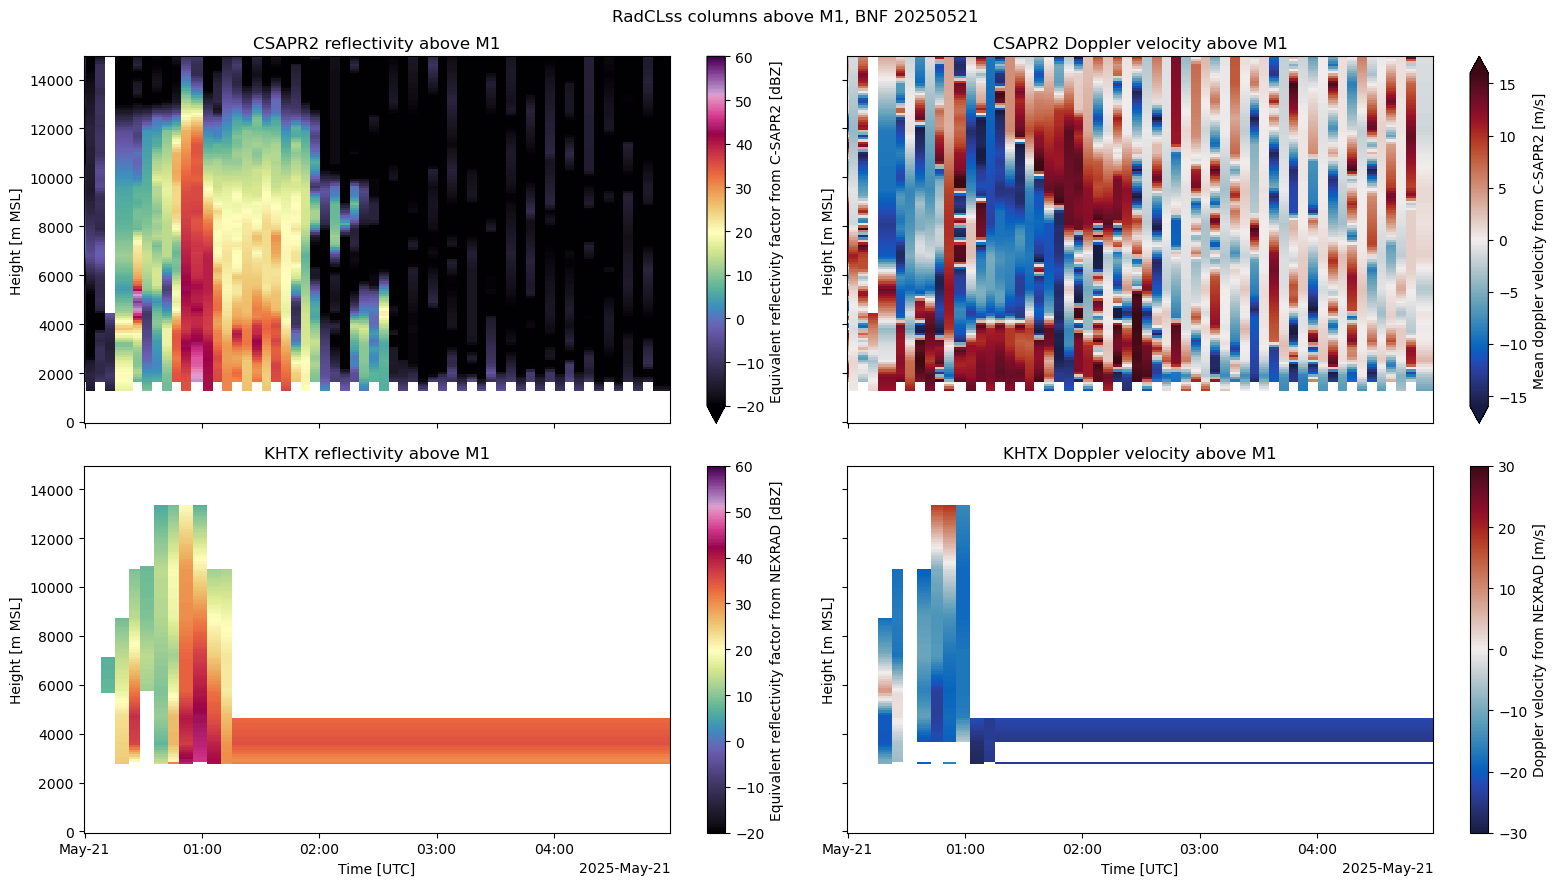

In [19]:
COLUMN_FIELDS = [
    ("csapr2_reflectivity", "CSAPR2 reflectivity", -20, 60, "ChaseSpectral"),
    ("csapr2_mean_doppler_velocity", "CSAPR2 Doppler velocity", -16, 16, "balance"),
    ("nexrad_reflectivity", "KHTX reflectivity", -20, 60, "ChaseSpectral"),
    ("nexrad_velocity", "KHTX Doppler velocity", -30, 30, "balance"),
]


def plot_column(ds, field, station, ax, vmin, vmax, cmap, title):
    """Plot the time-height column of one field above one station."""
    if field not in ds:
        ax.text(0.5, 0.5, f"{field}\nnot in output", ha="center", va="center")
        ax.set_axis_off()
        return None
    da = ds[field].sel(station=station)
    units = da.attrs.get("units", "")
    mesh = da.plot(
        x="time",
        y="height",
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        cbar_kwargs={"label": f"{da.attrs.get('long_name', field)} [{units}]"},
    )
    ax.set_title(f"{title} above {station}")
    ax.set_xlabel("Time [UTC]")
    ax.set_ylabel("Height [m MSL]")
    return mesh


fig, axarr = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
for ax, (field, title, vmin, vmax, cmap) in zip(axarr.flatten(), COLUMN_FIELDS):
    plot_column(my_columns, field, PLOT_STATION, ax, vmin, vmax, cmap, title)
for ax in axarr[0]:
    ax.set_xlabel("")
fig.suptitle(f"RadCLss columns above {PLOT_STATION}, {SITE.upper()} {DATE}")
fig.tight_layout()

The same field across every station, using the quicklook that ships with radclss. The columns are
extracted above each surface station, so this is the C-band reflectivity that each in-situ site saw
overhead.

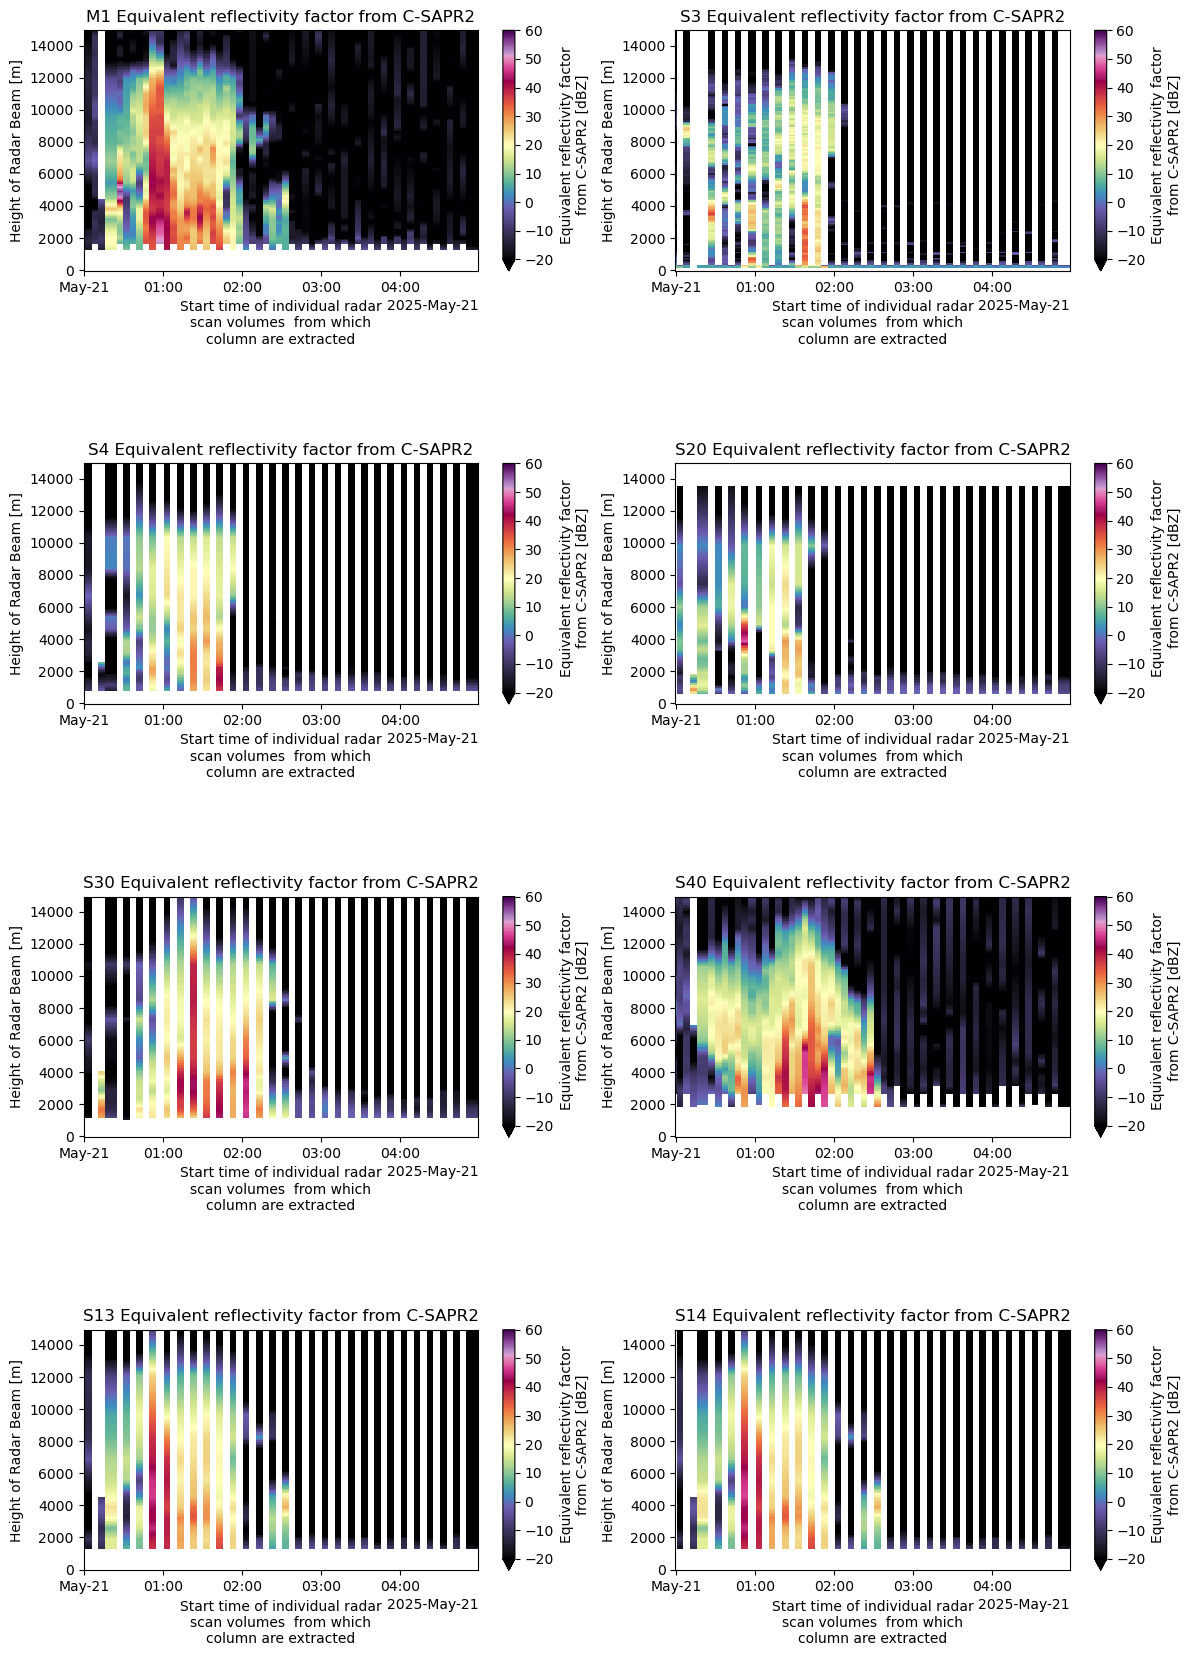

In [20]:
fig, axarr = radclss.vis.create_radclss_columns(
    my_columns, field="csapr2_reflectivity", vmin=-20, vmax=60
)

## 11. Precipitation rates and accumulation

The rates come from the disdrometers (`ldquants` at M1 and S30, `vdisquants` at M1) and the weighing
bucket gauge (`wbpluvio2` at M1), all resampled onto the column time grid.

The accumulation is integrated here rather than with `act.utils.accumulate_precip`, because that
helper only converts to mm when the units string is exactly `mm/hr`: `ldquants_rain_rate` arrives as
`mm/hour` and would be summed unconverted, giving an accumulation 60 times too large at 1 minute
sampling. `accumulate_rate` below accepts the spellings these datastreams actually use and
integrates over the real time steps.

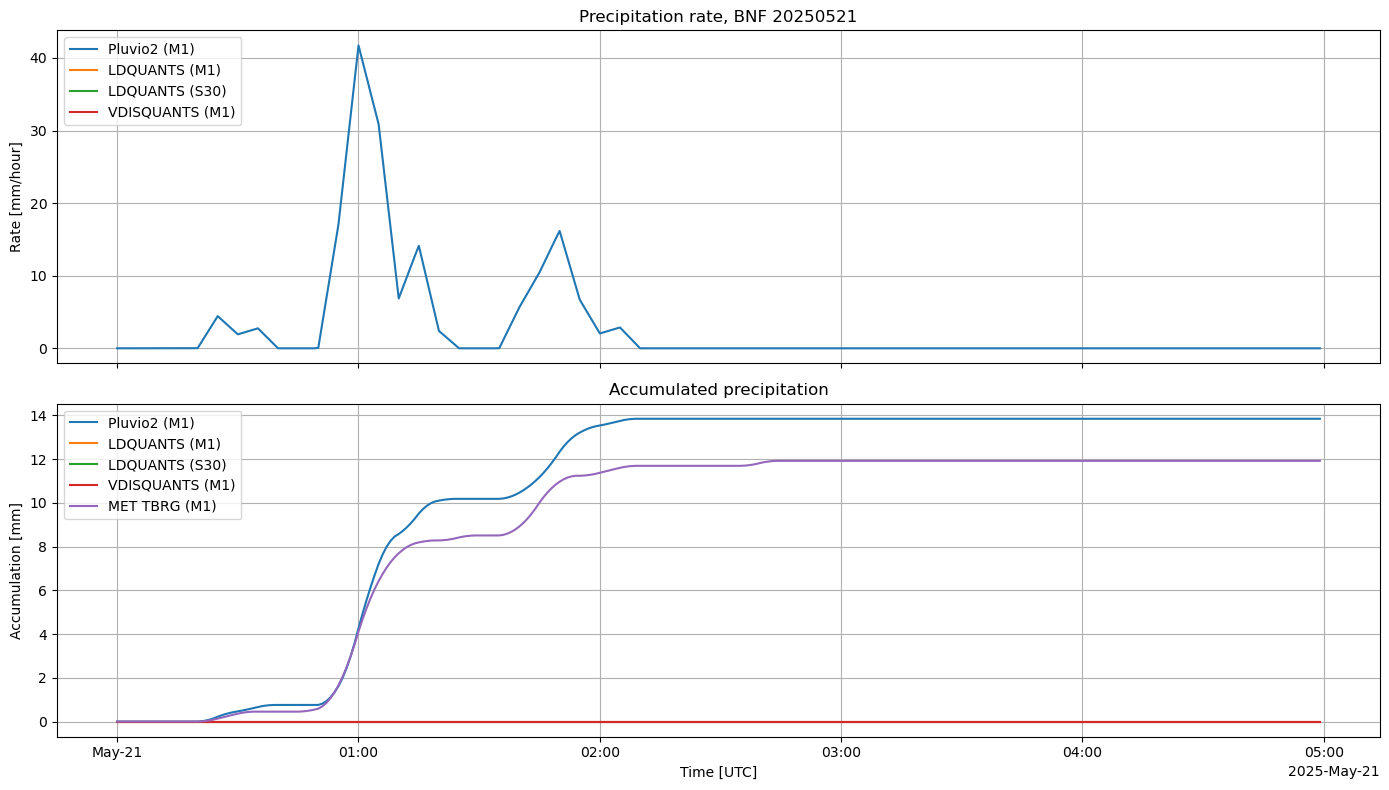

In [12]:
RATE_UNITS = ("mm/hr", "mm/hour", "mm/h", "mm h-1")

PRECIP_RATES = [
    ("intensity_rtnrt", "M1", "Pluvio2 (M1)"),
    ("ldquants_rain_rate", "M1", "LDQUANTS (M1)"),
    ("ldquants_rain_rate", "S30", "LDQUANTS (S30)"),
    ("vdisquants_rain_rate", "M1", "VDISQUANTS (M1)"),
]


def accumulate_rate(ds, field, station):
    """Integrate a precipitation rate over time, returning accumulation in mm."""
    da = ds[field].sel(station=station)
    units = da.attrs.get("units", "").strip().lower()
    if units not in RATE_UNITS:
        raise ValueError(f"{field} has units {units!r}, which is not a rate in mm/hour")
    seconds = np.diff(da["time"].values).astype("timedelta64[s]").astype(float)
    hours = np.concatenate([[0.0], seconds]) / 3600.0
    accumulated = np.cumsum(np.nan_to_num(da.values, nan=0.0) * hours)
    return xr.DataArray(
        accumulated,
        coords={"time": da["time"]},
        dims="time",
        attrs={"long_name": f"Accumulated {field}", "units": "mm"},
    )


fig, (ax_rate, ax_accum) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for field, station, label in PRECIP_RATES:
    if field not in my_columns:
        print(f"{field} is not in the output, skipping {label}")
        continue
    my_columns[field].sel(station=station).plot(x="time", ax=ax_rate, label=label)
    accumulate_rate(my_columns, field, station).plot(x="time", ax=ax_accum, label=label)

# The MET tipping bucket reports a per-interval total rather than a rate, so it
# accumulates with a plain cumulative sum.
if "tbrg_precip_total_corr" in my_columns:
    tbrg = my_columns["tbrg_precip_total_corr"].sel(station=PLOT_STATION)
    ax_accum.plot(
        tbrg["time"], np.nancumsum(tbrg.values), label=f"MET TBRG ({PLOT_STATION})"
    )

ax_rate.set_title(f"Precipitation rate, {SITE.upper()} {DATE}")
ax_rate.set_ylabel("Rate [mm/hour]")
ax_rate.set_xlabel("")
ax_accum.set_title("Accumulated precipitation")
ax_accum.set_ylabel("Accumulation [mm]")
ax_accum.set_xlabel("Time [UTC]")
for ax in (ax_rate, ax_accum):
    ax.legend(loc="upper left")
    ax.grid(True)
fig.tight_layout()

## What this notebook leaves out

Three pieces of the VAP have no counterpart here, all of them ADI's job rather than radclss':

- **The output DOD.** The VAP maps every variable into an ADI output dataset built from the
  `radclss.c0` DOD, so anything missing from the DOD is dropped with an error logged. Here the full
  radclss output is written, DOD or no DOD.
- **Missing value handling.** The VAP replaces NaN with each variable's DOD missing value before
  `dsproc.set_var_data`. This notebook first masks input `-9999` values as NaN so they do not plot
  as measurements; the netCDF writer retains the variable fill-value metadata.
- **Quicklooks and the processing loop.** `quicklook_hook` and ADI's interval loop, reprocessing
  flags and file naming are all outside this notebook; it runs one interval, once.